<a href="https://colab.research.google.com/github/nimitha123-kd/Take-IT-Smart-Internship/blob/main/Customer_Segmentation_KClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Project Title
#**Customer Segmentation using K-Means Clustering**



#**Problem Statement**

In today’s competitive market, businesses need to understand their customers to deliver personalized experiences and increase revenue. However, customers differ in terms of age, income, purchasing habits, and loyalty, making it difficult to target them effectively. This project aims to analyze customer purchasing behavior using features such as age, annual income, purchase amount, purchase frequency, region, and loyalty score. The objective is to group customers into meaningful segments based on their similarities.


#**Objective**

By performing customer segmentation, businesses can:

● Identify high-value and low-value customers

● Design targeted marketing strategies

● Improve customer retention and loyalty

● Optimize product recommendations

The dataset used is synthetic and created for learning purposes.

* Project Steps (End-to-End)
* Understanding the Problem
* Define objective: Segment customers
* Identify key features affecting behavior

**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load data**

In [ ]:
data = pd.read_csv('/content/Customer Purchasing Behaviors.csv')
data

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13
...,...,...,...,...,...,...,...
233,234,40,60000,450,7.2,West,20
234,235,38,59000,430,6.9,North,20
235,236,54,74000,630,9.4,South,27
236,237,32,52000,360,5.8,West,18


**Basic Checks**

In [ ]:
data.shape

(238, 7)

In [ ]:
data.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [ ]:
data.tail()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
233,234,40,60000,450,7.2,West,20
234,235,38,59000,430,6.9,North,20
235,236,54,74000,630,9.4,South,27
236,237,32,52000,360,5.8,West,18
237,238,31,51000,340,5.6,North,17


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB


In [ ]:
data.dtypes

,0
user_id,int64
age,int64
annual_income,int64
purchase_amount,int64
loyalty_score,float64
region,object
purchase_frequency,int64


In [ ]:
data.columns

Index(['user_id', 'age', 'annual_income', 'purchase_amount', 'loyalty_score',
       'region', 'purchase_frequency'],
      dtype='object')

In [ ]:
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
0,1,25,45000,200,4.5,12
1,2,34,55000,350,7.0,18
2,3,45,65000,500,8.0,22
3,4,22,30000,150,3.0,10
4,5,29,47000,220,4.8,13
...,...,...,...,...,...,...
233,234,40,60000,450,7.2,20
234,235,38,59000,430,6.9,20
235,236,54,74000,630,9.4,27
236,237,32,52000,360,5.8,18


In [ ]:
cat_cols = data.select_dtypes(include=['object'])
cat_cols

,region
0,North
1,South
2,West
3,East
4,North
...,...
233,West
234,North
235,South
236,West


In [ ]:
data.describe()

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,119.500000,38.676471,57407.563025,425.630252,6.794118,19.798319
std,68.848868,9.351118,11403.875717,140.052062,1.899047,4.562884
min,1.000000,22.000000,30000.000000,150.000000,3.000000,10.000000
25%,60.250000,31.000000,50000.000000,320.000000,5.500000,17.000000
50%,119.500000,39.000000,59000.000000,440.000000,7.000000,20.000000
75%,178.750000,46.750000,66750.000000,527.500000,8.275000,23.000000
max,238.000000,55.000000,75000.000000,640.000000,9.500000,28.000000


In [ ]:
# check for unique values
for x in cat_cols:
  print(x,'--->',data[x].unique())

region ---> ['North' 'South' 'West' 'East']


In [ ]:
# check for value counts
for x in cat_cols:
  print(data[x].value_counts())

region
North    78
South    77
West     77
East      6
Name: count, dtype: int64


**Data Cleaning**

**Check for missing values**

In [ ]:
data.isnull().sum()

,0
user_id,0
age,0
annual_income,0
purchase_amount,0
loyalty_score,0
region,0
purchase_frequency,0


**Check for duplicates**

In [ ]:
data.duplicated().sum()

np.int64(0)

**Exploratory data analysis**

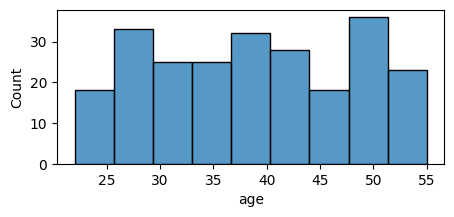

In [ ]:
# check distribution of age, annual income , purchase_amount, loyalty_score , purchase_frequency.
plt.figure(figsize=(5,2))
sns.histplot(data,x='age')
plt.show()

In [ ]:
data

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13
...,...,...,...,...,...,...,...
233,234,40,60000,450,7.2,West,20
234,235,38,59000,430,6.9,North,20
235,236,54,74000,630,9.4,South,27
236,237,32,52000,360,5.8,West,18


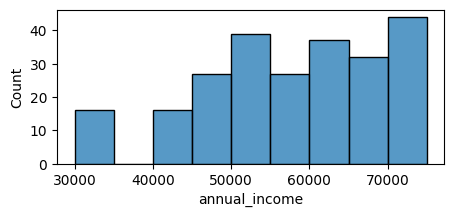

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='annual_income')
plt.show()

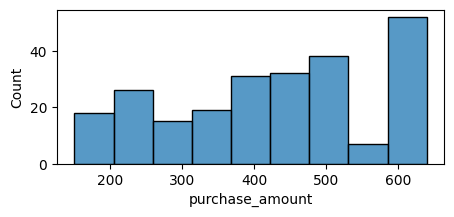

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='purchase_amount')
plt.show()

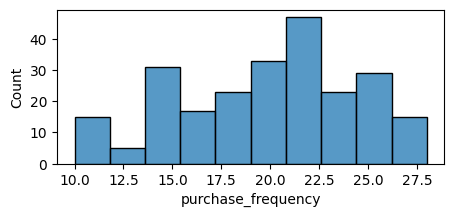

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='purchase_frequency')
plt.show()

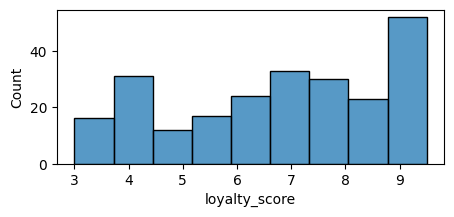

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='loyalty_score')
plt.show()

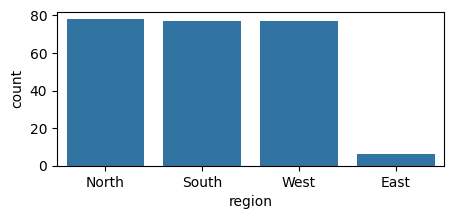

In [ ]:
# visualise the count of North , South , West , East
plt.figure(figsize=(5,2))
sns.countplot(data,x='region')
plt.show()

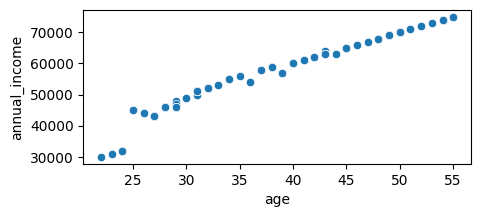

In [ ]:
# relationship between age and annual_income
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='age',y='annual_income')
plt.show()

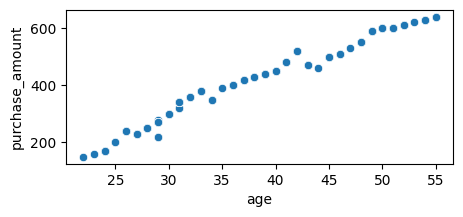

In [ ]:
# relationship between Age and Purchase Amount
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='age',y='purchase_amount')
plt.show()

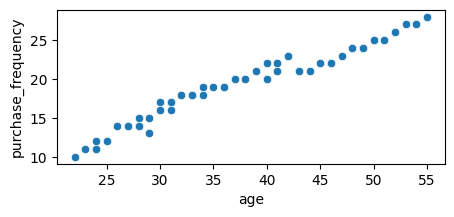

In [ ]:
# relationship between age & purchase_frequency
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='age',y='purchase_frequency')
plt.show()

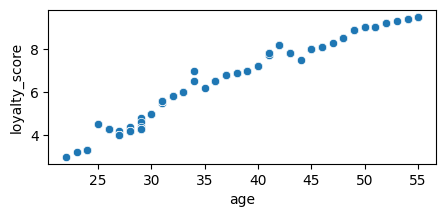

In [ ]:
# relationship between age & loyalty_score
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='age',y='loyalty_score')
plt.show()

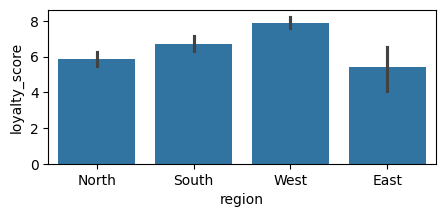

In [ ]:
# average  region , Loyalty_Score
plt.figure(figsize=(5,2))
sns.barplot(data,x='region',y='loyalty_score')
plt.show()

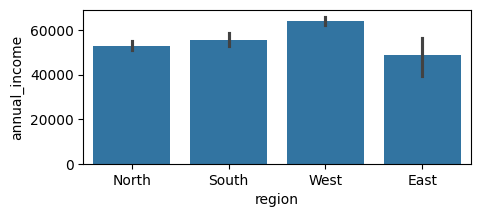

In [ ]:
# average  region & annual_income.
plt.figure(figsize=(5,2))
sns.barplot(data,x='region',y='annual_income')
plt.show()

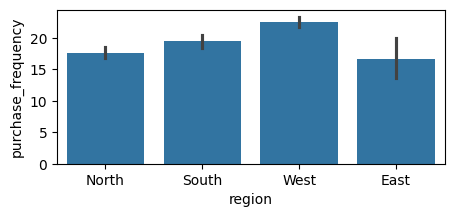

In [ ]:
# average  region & purchase_frequency
plt.figure(figsize=(5,2))
sns.barplot(data,x='region',y='purchase_frequency')
plt.show()

# Encoding

In [ ]:
# region --> one hot encoding
data = pd.get_dummies(data,columns=['region'],dtype='int')
data

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency,region_East,region_North,region_South,region_West
0,1,25,45000,200,4.5,12,0,1,0,0
1,2,34,55000,350,7.0,18,0,0,1,0
2,3,45,65000,500,8.0,22,0,0,0,1
3,4,22,30000,150,3.0,10,1,0,0,0
4,5,29,47000,220,4.8,13,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
233,234,40,60000,450,7.2,20,0,0,0,1
234,235,38,59000,430,6.9,20,0,1,0,0
235,236,54,74000,630,9.4,27,0,0,1,0
236,237,32,52000,360,5.8,18,0,0,0,1


# Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
model =  StandardScaler()
data[['age']]= model.fit_transform(data[['age']])
data[['annual_income']]= model.fit_transform(data[['annual_income']])
data[['purchase_amount']]= model.fit_transform(data[['purchase_amount']])
data[['purchase_frequency']]= model.fit_transform(data[['purchase_frequency']])
data[['loyalty_score']]= model.fit_transform(data[['loyalty_score']])




In [ ]:
# drop the user_id column
data.drop(columns='user_id',inplace=True)

# KMean Implementation

In [ ]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=2)
model.fit(data)

KMeans(n_clusters=2)

In [ ]:
df=data.copy()

In [ ]:
df['cluster']=model.predict(data)

In [ ]:
df["cluster"].unique()
# Since cluster = 2 , only two clusters will be shown .

array([0, 1], dtype=int32)

In [ ]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=3)
model.fit(data)

KMeans(n_clusters=3)

In [ ]:
df['cluster']=model.predict(data)

In [ ]:
df["cluster"].unique()

array([0, 2, 1], dtype=int32)

In [ ]:
labels= model.predict(data)

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(data,labels)

np.float64(0.4432036941273245)

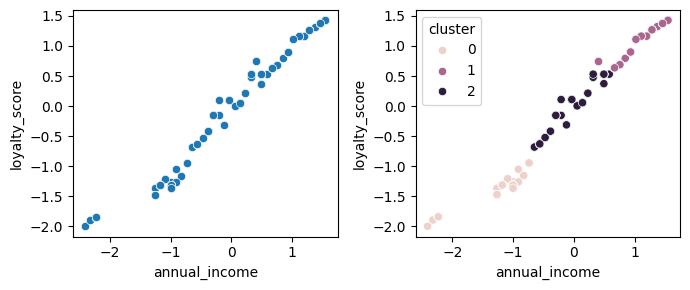

In [ ]:
# for visualization

fig, ax=plt.subplots(1,2,figsize=(7,3))
sns.scatterplot(df,x='annual_income',y='loyalty_score',ax=ax[0])
sns.scatterplot(df,x='annual_income',y='loyalty_score',hue='cluster',ax=ax[1])# Hue gives different colour to differnt values in aparticular column mentioned.
plt.tight_layout()

In [ ]:
df

,age,annual_income,purchase_amount,loyalty_score,purchase_frequency,region_East,region_North,region_South,region_West,cluster
0,-1.465632,-1.090306,-1.614441,-1.210582,-1.712679,0,1,0,0,0
1,-0.501151,-0.211563,-0.541153,0.108642,-0.394950,0,0,1,0,2
2,0.677658,0.667180,0.532134,0.636332,0.483536,0,0,0,1,1
3,-1.787125,-2.408420,-1.972203,-2.002117,-2.151922,1,0,0,0,0
4,-1.036974,-0.914557,-1.471336,-1.052275,-1.493057,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
233,0.141835,0.227809,0.174372,0.214180,0.044293,0,0,0,1,2
234,-0.072494,0.139934,0.031267,0.055873,0.044293,0,1,0,0,2
235,1.642138,1.458049,1.462317,1.375097,1.581644,0,0,1,0,1
236,-0.715480,-0.475186,-0.469601,-0.524586,-0.394950,0,0,0,1,2


In [ ]:
# Within Cluster Sum Of Squares.
wcss=[]
for k in range(2,11):
  model = KMeans(n_clusters=k)
  model.fit(data)
  wcss.append(model.inertia_)

In [ ]:
wcss

[487.9277273447416,
 296.9171011242052,
 221.16427233490882,
 209.44832774110458,
 148.0402024559652,
 130.6732150544586,
 109.03480725671974,
 95.19109695059952,
 93.5422876621076]

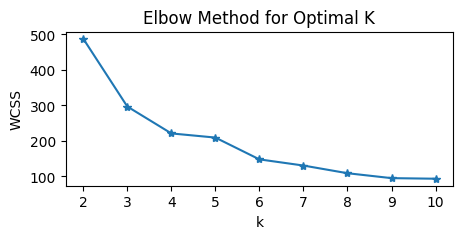

In [ ]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),wcss,marker='*')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

In [ ]:
model = KMeans(n_clusters=4)
model.fit(data)

KMeans(n_clusters=4)

In [ ]:
df1=data.copy()

In [ ]:
df1["cluster"] =model.predict(data)

In [ ]:
df1['cluster'].unique()

array([1, 2, 3, 0], dtype=int32)

In [ ]:
labels = model.predict(data)

In [ ]:
silhouette_score(data,labels)

np.float64(0.43221676473950177)

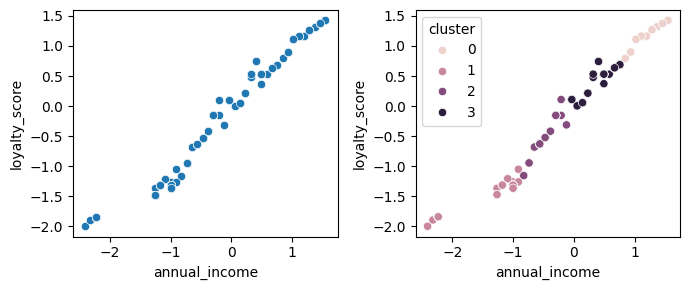

In [ ]:
# for visualization

fig, ax=plt.subplots(1,2,figsize=(7,3))
sns.scatterplot(df1,x='annual_income',y='loyalty_score',ax=ax[0])
sns.scatterplot(df1,x='annual_income',y='loyalty_score',hue='cluster',ax=ax[1])# Hue gives different colour to differnt values in a particular column mentioned.
plt.tight_layout()

#**📊 Result**

1️ .The scatter plot shows a strong positive relationship between annual income and loyalty score, meaning customers with higher income tend to be more loyal.

2️. The clustering algorithm divides customers into 4 distinct groups, where each group represents customers with similar income and loyalty behavior patterns.

- What the 4 Clusters Mean:
The 4 clusters represent different types of customers based on their purchasing behavior:
Cluster 0: Low income, low loyalty → low-value customers

Cluster 1: Medium income, moderate loyalty → potential customers

Cluster 2: High income, high loyalty → high-value (premium) customers

Cluster 3: Mixed or transitional behavior → inconsistent customers

These clusters are not predefined labels but are automatically formed groups of similar customers.


#**Final Conclusion**
The clustering analysis indicates a clear positive correlation between annual income and loyalty score, showing that customer loyalty increases with income level. The model successfully segments customers into four distinct groups based on similar behavioral patterns, although the separation between clusters is moderate. This segmentation helps in understanding customer distribution and highlights that most customers follow a structured pattern rather than random behavior.


#**Business Insights**
From a business perspective, high-income and highly loyal customers form the most valuable segment and should be prioritized through retention strategies such as rewards and personalized offers. Medium-level customers can be targeted with marketing efforts to increase their loyalty, while low-value customers may require minimal investment. Overall, the segmentation enables businesses to optimize marketing strategies, improve customer retention, and maximize revenue by focusing on the most profitable customer groups.